In [2]:
adata

NameError: name 'adata' is not defined

In [13]:
import scanpy as sc

adata= sc.read_h5ad('/home/Data_Drive_8TB_3/kykim/colon/SN123_A798015_Rep1_deconvol.h5ad')
# CTLA4 유전자의 위치를 찾음
if "CTLA4" in adata.var_names:
    ctla4_counts = adata[:, "CTLA4"].X.sum()
    print(f"CTLA4 유전자의 총 카운트: {ctla4_counts}")
else:
    print("CTLA4 유전자가 데이터에 없습니다.")


ImportError: Numba needs NumPy 2.0 or less. Got NumPy 2.1.

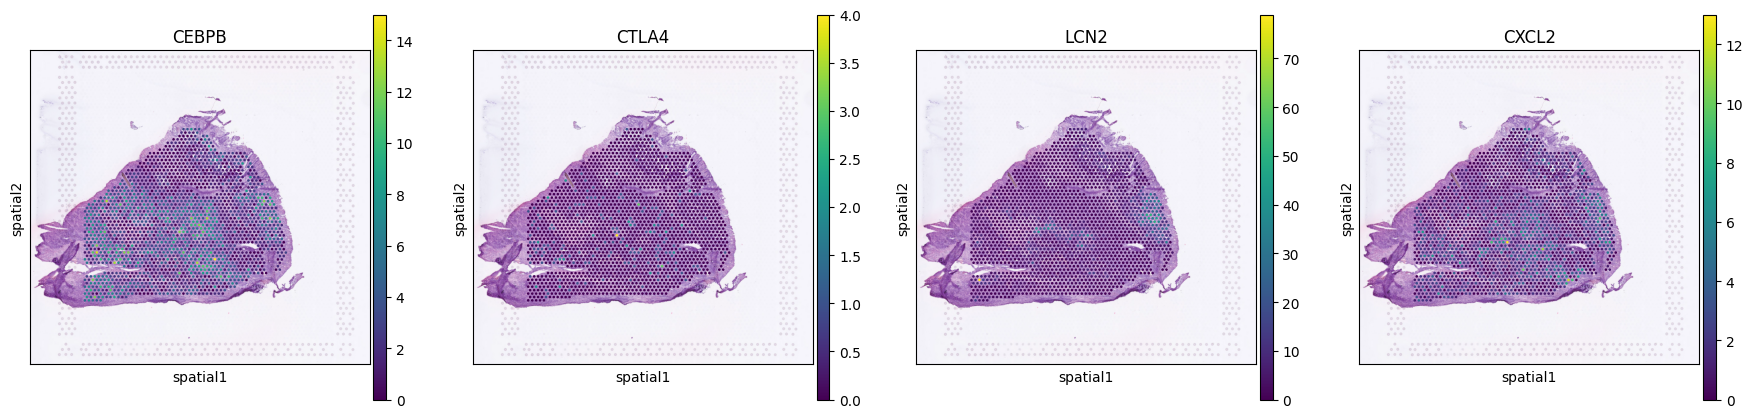

In [692]:
import matplotlib
import squidpy as sq

with matplotlib.rc_context({"figure.figsize": [4.5, 5]}):
    sq.pl.spatial_scatter(
        adata,
        color=["CEBPB","CTLA4","LCN2","CXCL2"]
    )

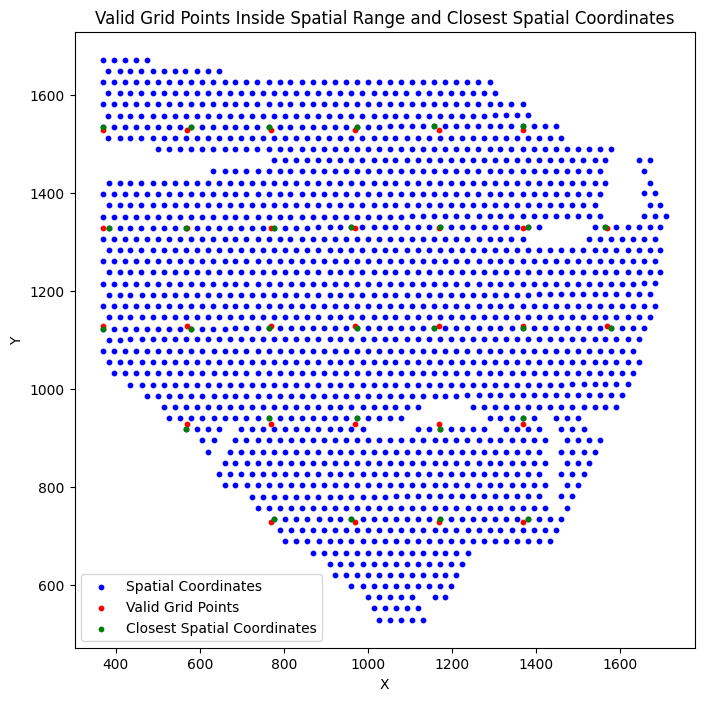

In [693]:
import numpy as np
import matplotlib.pyplot as plt

# Extract spatial coordinates from adata.obsm
spatial_coords = adata.obsm['spatial']

# Calculate the bounding box based on the spatial coordinates (ignoring empty spots)
x_min, x_max = np.min(spatial_coords[:, 0]), np.max(spatial_coords[:, 0])
y_min, y_max = np.min(spatial_coords[:, 1]), np.max(spatial_coords[:, 1])

# Generate grid points within the bounding box of spatial coordinates

grid_control = 200
#그리드 수 조정
x_grid = np.arange(x_min, x_max, grid_control)  # Adjust step size (50) if needed
y_grid = np.arange(y_min, y_max, grid_control)

# Create a grid of points within the specified bounds
grid_points = np.array(np.meshgrid(x_grid, y_grid)).T.reshape(-1, 2)

# Compute Euclidean distances manually (no cdist)
distances = np.sqrt(((grid_points[:, np.newaxis, :] - spatial_coords)**2).sum(axis=2))

# Find the closest spatial coordinate for each grid point
closest_spatial_indices = np.argmin(distances, axis=1)
closest_spatial_coords = spatial_coords[closest_spatial_indices]

# Calculate the minimum distance for each grid point and exclude those that are too far
min_distances = np.min(distances, axis=1)

# Define a distance threshold to exclude grid points that are too far
distance_threshold = 30  # Adjust this threshold as needed

# Filter grid points: keep only those with a minimum distance less than the threshold
valid_grid_points = grid_points[min_distances < distance_threshold]
valid_closest_spatial_coords = closest_spatial_coords[min_distances < distance_threshold]

# Create plot
plt.figure(figsize=(8, 8))

# Plot original spatial coordinates in blue
plt.scatter(spatial_coords[:, 0], spatial_coords[:, 1], color='blue', label='Spatial Coordinates', s=10)

# Plot valid grid points (red) and their matched closest spatial coordinates (green)
plt.scatter(valid_grid_points[:, 0], valid_grid_points[:, 1], color='red', label='Valid Grid Points', s=10)
plt.scatter(valid_closest_spatial_coords[:, 0], valid_closest_spatial_coords[:, 1], color='green', label='Closest Spatial Coordinates', s=10)

# Adding labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Valid Grid Points Inside Spatial Range and Closest Spatial Coordinates')
plt.legend()

plt.show()


In [694]:
import numpy as np

# Extract spatial coordinates from adata.obsm
spatial_coords = adata.obsm['spatial']

# Now, valid_closest_spatial_coords is the list of coordinates that are valid grid points
# valid_closest_spatial_coords is already computed in the previous steps
valid_closest_spatial_coords = valid_closest_spatial_coords

# Initialize an empty list to store the closest coordinates from valid_closest_spatial_coords
spatial_bulked = []

# For each spatial coordinate in adata.obsm['spatial'], find the closest one from valid_closest_spatial_coords
for spatial_coord in spatial_coords:
    # Compute the Euclidean distance to each of the valid_closest_spatial_coords
    distances = np.sqrt(((valid_closest_spatial_coords - spatial_coord) ** 2).sum(axis=1))
    
    # Find the index of the closest valid_closest_spatial_coord
    closest_index = np.argmin(distances)
    
    # Append the closest valid coordinate to the spatial_bulked list
    spatial_bulked.append(valid_closest_spatial_coords[closest_index])

# Convert spatial_bulked list to a numpy array
spatial_bulked = np.array(spatial_bulked)

# Save the results in adata.obsm['spatial_bulked']
adata.obsm['spatial_bulked'] = spatial_bulked

# Optionally, to ensure uniqueness, we can check that the unique values of the bulked coordinates
# match the number of valid grid points (should be same length)
assert len(np.unique(spatial_bulked, axis=0)) == len(valid_closest_spatial_coords)

# Extract unique values from adata.obsm['spatial_bulked']
unique_spatial_bulked = np.unique(adata.obsm['spatial_bulked'], axis=0)

# Print the unique values
print(f"Unique values in adata.obsm['spatial_bulked']:")
print(unique_spatial_bulked)

# Optionally, print the number of unique points
print(f"Number of unique points in adata.obsm['spatial_bulked']: {len(unique_spatial_bulked)}")



Unique values in adata.obsm['spatial_bulked']:
[[ 369 1535]
 [ 370 1123]
 [ 383 1329]
 [ 567  918]
 [ 567 1329]
 [ 580 1123]
 [ 580 1535]
 [ 764  941]
 [ 764 1124]
 [ 764 1535]
 [ 777  735]
 [ 777 1329]
 [ 961  735]
 [ 961 1330]
 [ 974  941]
 [ 974 1124]
 [ 974 1535]
 [1158 1124]
 [1158 1536]
 [1171 1330]
 [1172  735]
 [1172  918]
 [1369  941]
 [1369 1124]
 [1369 1536]
 [1382  735]
 [1382 1330]
 [1566 1330]
 [1579 1124]]
Number of unique points in adata.obsm['spatial_bulked']: 29


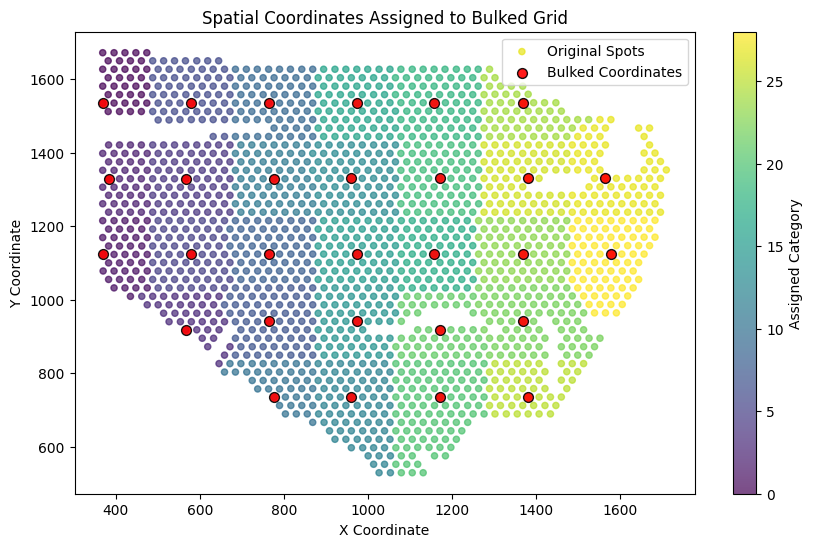

Number of unique bulked coordinates: 29
Number of original coordinates: 1803
Assigned categories: 29
       x     y  count
0   1172   735     96
1   1369   941     82
2    961   735     79
3   1579  1124     77
4   1566  1330     72
5    764   941     71
6    961  1330     70
7   1158  1536     70
8    567  1329     68
9   1369  1124     68
10  1171  1330     67
11  1382  1330     66
12   580  1123     65
13   764  1535     65
14   777  1329     65
15   974  1535     65
16  1158  1124     63
17   974   941     63
18   764  1124     62
19   580  1535     61
20   974  1124     60
21  1369  1536     54
22  1382   735     50
23  1172   918     49
24   370  1123     41
25   777   735     41
26   383  1329     40
27   567   918     37
28   369  1535     36

Count distribution (how many rows have the same count):
count
65    4
63    2
41    2
70    2
68    2
61    1
37    1
40    1
49    1
50    1
54    1
60    1
96    1
62    1
82    1
66    1
67    1
71    1
72    1
77    1
79    1
36    1


In [695]:
import numpy as np
import matplotlib.pyplot as plt

# adata.obsm 데이터 불러오기
spatial_coords = adata.obsm['spatial']  # 원본 좌표
bulk_coords = np.unique(adata.obsm['spatial_bulked'], axis=0)  # bulked 좌표의 고유값

# bulk_coords에 유클리드 거리 기준으로 spatial_coords를 할당
assigned_bulk_indices = []
categories = []

for coord in spatial_coords:
    # 각 원본 좌표와 bulk 좌표 간의 거리 계산
    distances = np.linalg.norm(bulk_coords - coord, axis=1)
    
    # 가장 가까운 bulk 좌표의 인덱스 찾기
    closest_index = np.argmin(distances)
    categories.append(closest_index)
    assigned_bulk_indices.append(bulk_coords[closest_index])

# 할당 결과 numpy 배열로 변환
assigned_bulk_indices = np.array(assigned_bulk_indices)
categories = np.array(categories)

# 시각화: 좌표 분포 및 할당된 결과 확인
plt.figure(figsize=(10, 6))

# 기존 spatial 좌표 표시
scatter = plt.scatter(spatial_coords[:, 0], spatial_coords[:, 1], c=categories, cmap='viridis', label='Original Spots', alpha=0.7, s=20)

# bulk 좌표 강조
plt.scatter(bulk_coords[:, 0], bulk_coords[:, 1], c='red', label='Bulked Coordinates', alpha=0.9, s=50, edgecolor='black')

# 라벨과 제목 설정
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Spatial Coordinates Assigned to Bulked Grid')

# 레전드 설정
plt.legend()

# 카테고리 색상 바 표시
plt.colorbar(scatter, label='Assigned Category')

# 결과 표시
plt.show()

# adata 객체에 새로운 'bulkX' 저장
adata.obsm['spatial_bulked'] = assigned_bulk_indices

# 결과 출력
print(f"Number of unique bulked coordinates: {bulk_coords.shape[0]}")
print(f"Number of original coordinates: {spatial_coords.shape[0]}")
print(f"Assigned categories: {np.unique(categories).shape[0]}")

import numpy as np
import pandas as pd

# spatial_bulked 데이터를 가져옵니다.
spatial_bulked = adata.obsm['spatial_bulked']

# pandas DataFrame으로 변환 (numpy 배열의 고유 행 카운트를 편리하게 계산하기 위함)
spatial_bulked_df = pd.DataFrame(spatial_bulked, columns=['x', 'y'])

# 각 고유 행의 중복 개수를 계산
row_counts = spatial_bulked_df.value_counts()

# 결과를 DataFrame 형태로 정리
row_counts_df = row_counts.reset_index()
row_counts_df.columns = ['x', 'y', 'count']

# 결과 확인
print(row_counts_df)

# 중복 개수 통계 확인 (예: 각 중복 개수가 몇 번 나타나는지)
print("\nCount distribution (how many rows have the same count):")
print(row_counts_df['count'].value_counts())

# 특정 좌표의 중복 개수 확인 (예: 첫 번째 좌표)
example_coord = tuple(row_counts_df.iloc[0][['x', 'y']])
print(f"\nThe coordinate {example_coord} appears {row_counts_df.iloc[0]['count']} times.")


In [696]:
import numpy as np

# 원본 좌표와 bulked 좌표 불러오기
original_coords = adata.obsm['spatial']
bulked_coords = adata.obsm['spatial_bulked']

# bulked 좌표들이 원본 좌표에 모두 포함되는지 확인
invalid_coords = []
for coord in bulked_coords:
    if not np.any(np.all(original_coords == coord, axis=1)):
        invalid_coords.append(coord)

# 결과 출력
if invalid_coords:
    print(f"총 {len(invalid_coords)}개의 bulked 좌표가 원본 좌표에 없습니다.")
    print("유효하지 않은 bulked 좌표:")
    print(np.array(invalid_coords))
else:
    print("모든 bulked 좌표가 원본 좌표에 포함되어 있습니다.")


모든 bulked 좌표가 원본 좌표에 포함되어 있습니다.


In [697]:
# 길이 비교
length_spatial = adata.obsm['spatial'].shape[0]
length_spatial_bulked = adata.obsm['spatial_bulked'].shape[0]

# 결과 출력
if length_spatial == length_spatial_bulked:
    print(f"두 좌표 배열의 길이가 동일합니다: {length_spatial}")
else:
    print(f"좌표 배열의 길이가 다릅니다!")
    print(f"원본 좌표 길이: {length_spatial}")
    print(f"bulk 좌표 길이: {length_spatial_bulked}")


두 좌표 배열의 길이가 동일합니다: 1803


In [698]:
import numpy as np
import pandas as pd

# 원본 좌표와 bulk 좌표 불러오기
original_coords = adata.obsm['spatial']  # (n_spots, 2) 좌표
bulked_coords = adata.obsm['spatial_bulked']  # 축소된 bulk 좌표

# 유전자 발현 값 (adata.X)
expression_matrix = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X  # (n_spots, n_genes)

# adata.obsm['spatial_bulked']를 문자열로 변환하여 고유값 식별
bulk_coord_str = np.array(['_'.join(map(str, coord)) for coord in bulked_coords])

# bulked_coords에서 고유한 좌표별로 그룹화
unique_bulk_coords, inverse_indices = np.unique(bulk_coord_str, return_inverse=True)

# bulk 표현을 위한 빈 배열 생성
bulkX = np.zeros(expression_matrix.shape)

# 동일한 bulk 좌표끼리 그룹화하여 발현값 평균 계산
for idx, unique_coord in enumerate(unique_bulk_coords):
    # 현재 bulked 좌표와 동일한 값의 인덱스를 찾음
    matching_indices = np.where(inverse_indices == idx)[0]
    
    # 해당 그룹의 유전자 발현 값의 평균을 계산
    mean_expression = expression_matrix[matching_indices, :].mean(axis=0)
    
    # 동일한 bulk 좌표에 속하는 모든 인덱스에 대해 평균 발현 값을 할당
    bulkX[matching_indices, :] = mean_expression

# 결과를 adata 객체에 저장
adata.layers['bulkX'] = bulkX

# 결과 확인
print(f"bulkX의 크기: {bulkX.shape}")

# 각 bulk 좌표에 대해 발현 값이 동일한지 확인
unique_bulk_values = np.unique(bulkX, axis=0)
print(f"Unique values in bulkX (should be the same for each bulked coordinate): {unique_bulk_values.shape[0]}")


bulkX의 크기: (1803, 15136)
Unique values in bulkX (should be the same for each bulked coordinate): 29


In [699]:
import pandas as pd

# bulkX를 DataFrame으로 변환
bulkX_df = pd.DataFrame(
    adata.layers['bulkX'], 
    columns=adata.var_names  # 유전자 이름을 열 이름으로 사용
)

# 유니크한 행(row)을 계산
unique_bulkX_df = bulkX_df.drop_duplicates()

# 유니크 행(row)의 개수
num_unique_bulkX_rows = unique_bulkX_df.shape[0]

# 결과 출력
print(f"Unique bulkX 행(row)의 수: {num_unique_bulkX_rows}")


Unique bulkX 행(row)의 수: 29


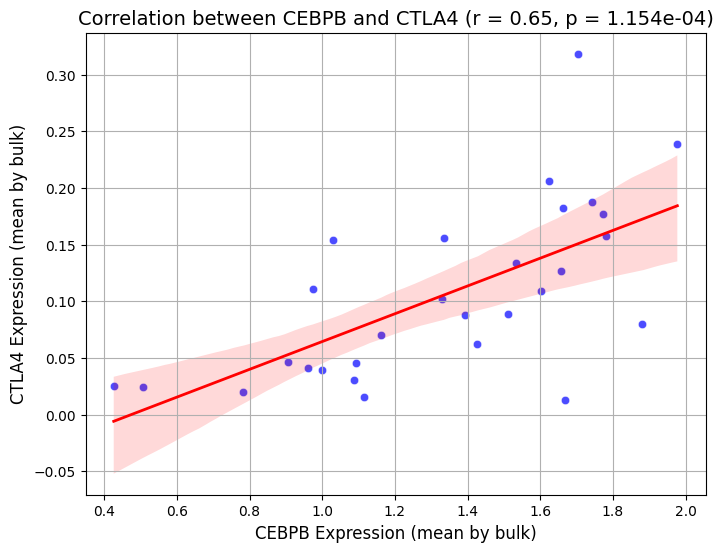

Pearson correlation coefficient: 0.65
P-value: 1.154e-04
Number of unique coordinates: 29


In [700]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np
from scipy.stats import zscore

# 유전자 이름
gene_1 = 'CEBPB'
gene_2 = 'CTLA4'

# 데이터 추출
bulkX = adata.layers['bulkX']
spatial_bulked = adata.obsm['spatial_bulked']

# 유전자 이름에 해당하는 인덱스 찾기
gene_1_index = np.where(adata.var_names == gene_1)[0][0]
gene_2_index = np.where(adata.var_names == gene_2)[0][0]

# 'spatial_bulked'에서 고유 좌표 찾기
unique_bulked_coords, inverse_indices = np.unique(spatial_bulked, axis=0, return_inverse=True)

# 고유 좌표별 발현값을 저장할 배열 생성
n_unique_coords = unique_bulked_coords.shape[0]
unique_gene_1_expression = np.zeros(n_unique_coords)
unique_gene_2_expression = np.zeros(n_unique_coords)

# 고유 좌표별로 유전자 발현값 합산
for idx in range(n_unique_coords):
    # 각 고유 좌표에 속한 인덱스 선택
    matching_indices = np.where(inverse_indices == idx)[0]

    # 고유 좌표에 해당하는 유전자 발현값 합산
    unique_gene_1_expression[idx] = bulkX[matching_indices, gene_1_index].mean()
    unique_gene_2_expression[idx] = bulkX[matching_indices, gene_2_index].mean()
# NaN 값을 0으로 변환
unique_gene_1_expression = np.nan_to_num(unique_gene_1_expression, nan=0)
unique_gene_2_expression = np.nan_to_num(unique_gene_2_expression, nan=0)

# # Z-Score 전처리
# unique_gene_1_expression = zscore(unique_gene_1_expression)
# unique_gene_2_expression = zscore(unique_gene_2_expression)

# Log 전처리 (log1p는 log(x+1) 형태로, 0 또는 음수값 처리)
unique_gene_1_expression = np.log1p(unique_gene_1_expression)
unique_gene_2_expression = np.log1p(unique_gene_2_expression)

# 고유 좌표 기반 Pearson 상관계수 계산
correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)

# 결과 시각화
plt.figure(figsize=(8, 6))

# 산점도
sns.scatterplot(x=unique_gene_1_expression, y=unique_gene_2_expression, color='blue', alpha=0.7)

# 회귀선 추가
sns.regplot(
    x=unique_gene_1_expression,
    y=unique_gene_2_expression,
    scatter=False,
    color='red',
    line_kws={"color": "red", "lw": 2},
)

# 플롯 설정
plt.title(f"Correlation between {gene_1} and {gene_2} (r = {correlation:.2f}, p = {p_value:.3e})", fontsize=14)
plt.xlabel(f"{gene_1} Expression (mean by bulk)", fontsize=12)
plt.ylabel(f"{gene_2} Expression (mean by bulk)", fontsize=12)
plt.grid(True)

# 플롯 표시
plt.show()

# 상관계수 및 p-value 출력
print(f"Pearson correlation coefficient: {correlation:.2f}")
print(f"P-value: {p_value:.3e}")
print(f"Number of unique coordinates: {n_unique_coords}")


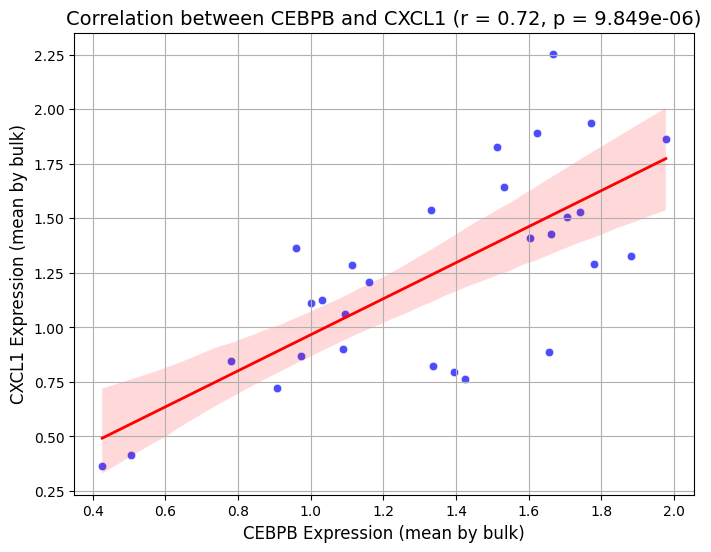

Pearson correlation coefficient: 0.72
P-value: 9.849e-06
Number of unique coordinates: 29


In [707]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np
from scipy.stats import zscore

# 유전자 이름
gene_1 = 'CEBPB'
gene_2 = 'CXCL1'

# 데이터 추출
bulkX = adata.layers['bulkX']
spatial_bulked = adata.obsm['spatial_bulked']

# 유전자 이름에 해당하는 인덱스 찾기
gene_1_index = np.where(adata.var_names == gene_1)[0][0]
gene_2_index = np.where(adata.var_names == gene_2)[0][0]

# 'spatial_bulked'에서 고유 좌표 찾기
unique_bulked_coords, inverse_indices = np.unique(spatial_bulked, axis=0, return_inverse=True)

# 고유 좌표별 발현값을 저장할 배열 생성
n_unique_coords = unique_bulked_coords.shape[0]
unique_gene_1_expression = np.zeros(n_unique_coords)
unique_gene_2_expression = np.zeros(n_unique_coords)

# 고유 좌표별로 유전자 발현값 합산
for idx in range(n_unique_coords):
    # 각 고유 좌표에 속한 인덱스 선택
    matching_indices = np.where(inverse_indices == idx)[0]

    # 고유 좌표에 해당하는 유전자 발현값 합산
    unique_gene_1_expression[idx] = bulkX[matching_indices, gene_1_index].mean()
    unique_gene_2_expression[idx] = bulkX[matching_indices, gene_2_index].mean()
# NaN 값을 0으로 변환
unique_gene_1_expression = np.nan_to_num(unique_gene_1_expression, nan=0)
unique_gene_2_expression = np.nan_to_num(unique_gene_2_expression, nan=0)

# # Z-Score 전처리
# unique_gene_1_expression = zscore(unique_gene_1_expression)
# unique_gene_2_expression = zscore(unique_gene_2_expression)

# Log 전처리 (log1p는 log(x+1) 형태로, 0 또는 음수값 처리)
unique_gene_1_expression = np.log1p(unique_gene_1_expression)
unique_gene_2_expression = np.log1p(unique_gene_2_expression)

# 고유 좌표 기반 Pearson 상관계수 계산
correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)

# 결과 시각화
plt.figure(figsize=(8, 6))

# 산점도
sns.scatterplot(x=unique_gene_1_expression, y=unique_gene_2_expression, color='blue', alpha=0.7)

# 회귀선 추가
sns.regplot(
    x=unique_gene_1_expression,
    y=unique_gene_2_expression,
    scatter=False,
    color='red',
    line_kws={"color": "red", "lw": 2},
)

# 플롯 설정
plt.title(f"Correlation between {gene_1} and {gene_2} (r = {correlation:.2f}, p = {p_value:.3e})", fontsize=14)
plt.xlabel(f"{gene_1} Expression (mean by bulk)", fontsize=12)
plt.ylabel(f"{gene_2} Expression (mean by bulk)", fontsize=12)
plt.grid(True)

# 플롯 표시
plt.show()

# 상관계수 및 p-value 출력
print(f"Pearson correlation coefficient: {correlation:.2f}")
print(f"P-value: {p_value:.3e}")
print(f"Number of unique coordinates: {n_unique_coords}")


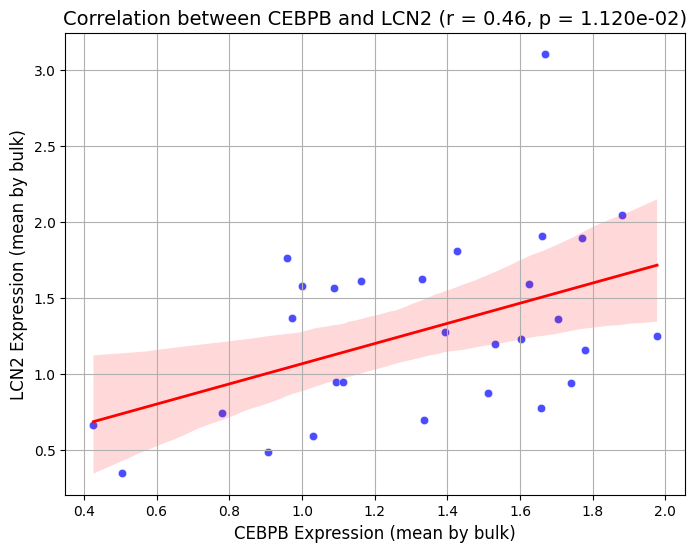

Pearson correlation coefficient: 0.46
P-value: 1.120e-02
Number of unique coordinates: 29


In [702]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np
from scipy.stats import zscore

# 유전자 이름
gene_1 = 'CEBPB'
gene_2 = 'LCN2'

# 데이터 추출
bulkX = adata.layers['bulkX']
spatial_bulked = adata.obsm['spatial_bulked']

# 유전자 이름에 해당하는 인덱스 찾기
gene_1_index = np.where(adata.var_names == gene_1)[0][0]
gene_2_index = np.where(adata.var_names == gene_2)[0][0]

# 'spatial_bulked'에서 고유 좌표 찾기
unique_bulked_coords, inverse_indices = np.unique(spatial_bulked, axis=0, return_inverse=True)

# 고유 좌표별 발현값을 저장할 배열 생성
n_unique_coords = unique_bulked_coords.shape[0]
unique_gene_1_expression = np.zeros(n_unique_coords)
unique_gene_2_expression = np.zeros(n_unique_coords)

# 고유 좌표별로 유전자 발현값 합산
for idx in range(n_unique_coords):
    # 각 고유 좌표에 속한 인덱스 선택
    matching_indices = np.where(inverse_indices == idx)[0]

    # 고유 좌표에 해당하는 유전자 발현값 합산
    unique_gene_1_expression[idx] = bulkX[matching_indices, gene_1_index].mean()
    unique_gene_2_expression[idx] = bulkX[matching_indices, gene_2_index].mean()
# NaN 값을 0으로 변환
unique_gene_1_expression = np.nan_to_num(unique_gene_1_expression, nan=0)
unique_gene_2_expression = np.nan_to_num(unique_gene_2_expression, nan=0)

# # Z-Score 전처리
# unique_gene_1_expression = zscore(unique_gene_1_expression)
# unique_gene_2_expression = zscore(unique_gene_2_expression)

# Log 전처리 (log1p는 log(x+1) 형태로, 0 또는 음수값 처리)
unique_gene_1_expression = np.log1p(unique_gene_1_expression)
unique_gene_2_expression = np.log1p(unique_gene_2_expression)

# 고유 좌표 기반 Pearson 상관계수 계산
correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)

# 결과 시각화
plt.figure(figsize=(8, 6))

# 산점도
sns.scatterplot(x=unique_gene_1_expression, y=unique_gene_2_expression, color='blue', alpha=0.7)

# 회귀선 추가
sns.regplot(
    x=unique_gene_1_expression,
    y=unique_gene_2_expression,
    scatter=False,
    color='red',
    line_kws={"color": "red", "lw": 2},
)

# 플롯 설정
plt.title(f"Correlation between {gene_1} and {gene_2} (r = {correlation:.2f}, p = {p_value:.3e})", fontsize=14)
plt.xlabel(f"{gene_1} Expression (mean by bulk)", fontsize=12)
plt.ylabel(f"{gene_2} Expression (mean by bulk)", fontsize=12)
plt.grid(True)

# 플롯 표시
plt.show()

# 상관계수 및 p-value 출력
print(f"Pearson correlation coefficient: {correlation:.2f}")
print(f"P-value: {p_value:.3e}")
print(f"Number of unique coordinates: {n_unique_coords}")


/tmp/ipykernel_1082886/3738199508.py:35: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)
/tmp/ipykernel_1082886/3738199508.py:54: RuntimeWarning: divide by zero encountered in log10
  sns.histplot(-np.log10(np.nan_to_num(p_value_list, nan=1.0)), bins=30, kde=True, color='red')


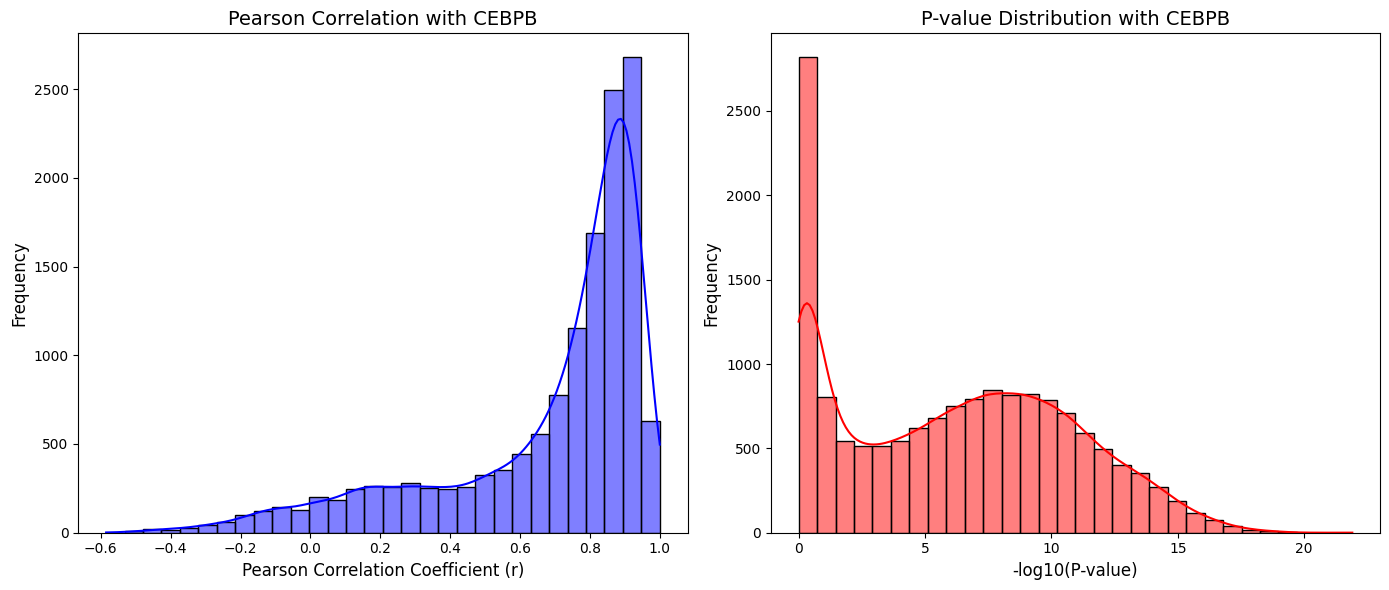

In [703]:
# Pearson 상관계수와 P-value를 저장할 리스트 초기화
correlation_list = []
p_value_list = []

# CEBPB 유전자의 인덱스
gene_1_index = np.where(adata.var_names == gene_1)[0][0]

# 고유 좌표 및 각 좌표의 인덱스 가져오기
unique_coords, inverse_indices = np.unique(spatial_bulked, axis=0, return_inverse=True)

# 모든 유전자에 대해 CEBPB와 Pearson 상관계수 계산
for gene_name in adata.var_names:
    gene_2_index = np.where(adata.var_names == gene_name)[0][0]
    
    # 고유 좌표별 발현값 평균 계산
    unique_gene_1_expression = np.array([
        bulkX[inverse_indices == idx, gene_1_index].mean()
        for idx in range(len(unique_coords))
    ])
    unique_gene_2_expression = np.array([
        bulkX[inverse_indices == idx, gene_2_index].mean()
        for idx in range(len(unique_coords))
    ])
    
    # NaN을 0으로 대체
    unique_gene_1_expression = np.nan_to_num(unique_gene_1_expression, nan=0)
    unique_gene_2_expression = np.nan_to_num(unique_gene_2_expression, nan=0)
    
    # Log 전처리
    unique_gene_1_expression = np.log1p(unique_gene_1_expression)
    unique_gene_2_expression = np.log1p(unique_gene_2_expression)
    
    # Pearson 상관계수 및 p-value 계산
    if len(unique_gene_1_expression) > 1 and len(unique_gene_2_expression) > 1:
        correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)
    else:
        correlation, p_value = np.nan, np.nan  # 데이터가 부족한 경우 처리
    
    correlation_list.append(correlation)
    p_value_list.append(p_value)

# 히스토그램 시각화
plt.figure(figsize=(14, 6))

# Pearson 상관계수 히스토그램
plt.subplot(1, 2, 1)
sns.histplot(correlation_list, bins=30, kde=True, color='blue')
plt.title(f"Pearson Correlation with {gene_1}", fontsize=14)
plt.xlabel("Pearson Correlation Coefficient (r)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# P-value 히스토그램 (log 스케일)
plt.subplot(1, 2, 2)
sns.histplot(-np.log10(np.nan_to_num(p_value_list, nan=1.0)), bins=30, kde=True, color='red')
plt.title(f"P-value Distribution with {gene_1}", fontsize=14)
plt.xlabel("-log10(P-value)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1082886/3588809473.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)
/tmp/ipykernel_1082886/3588809473.py:55: RuntimeWarning: divide by zero encountered in log10
  sns.histplot(-np.log10(np.nan_to_num(p_value_list, nan=1.0)), bins=30, kde=True, color='red')


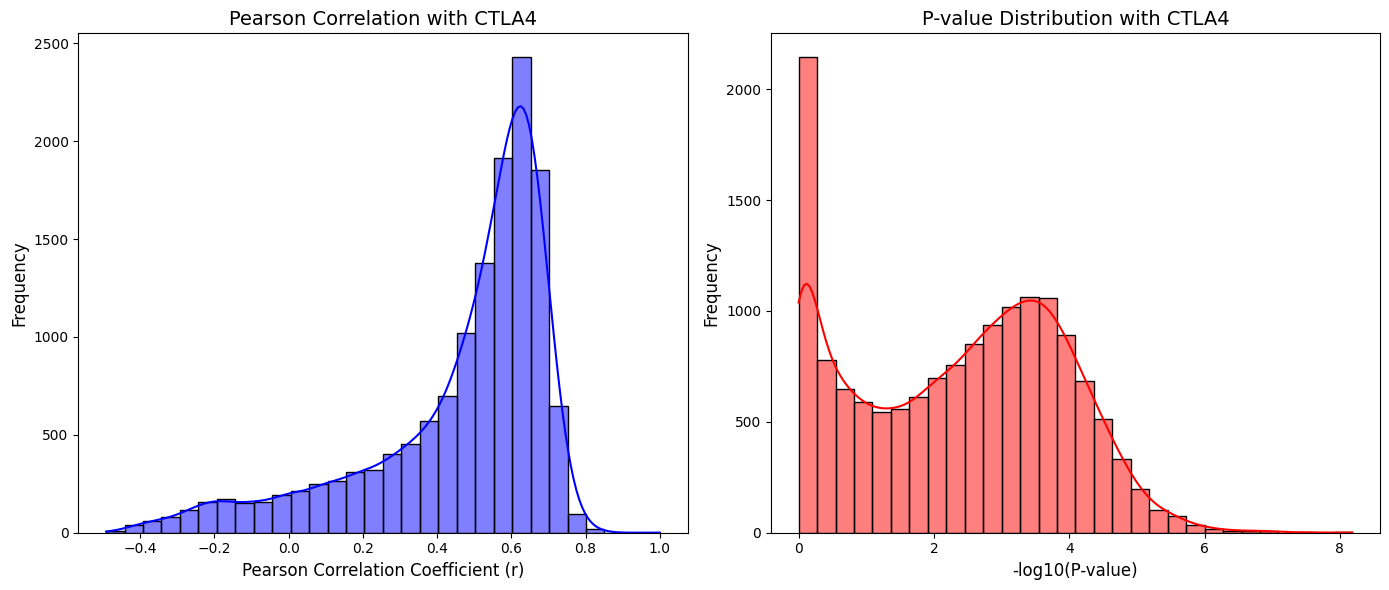

In [704]:
gene_1 = 'CTLA4'
# Pearson 상관계수와 P-value를 저장할 리스트 초기화
correlation_list = []
p_value_list = []

# CEBPB 유전자의 인덱스
gene_1_index = np.where(adata.var_names == gene_1)[0][0]

# 고유 좌표 및 각 좌표의 인덱스 가져오기
unique_coords, inverse_indices = np.unique(spatial_bulked, axis=0, return_inverse=True)

# 모든 유전자에 대해 CEBPB와 Pearson 상관계수 계산
for gene_name in adata.var_names:
    gene_2_index = np.where(adata.var_names == gene_name)[0][0]
    
    # 고유 좌표별 발현값 평균 계산
    unique_gene_1_expression = np.array([
        bulkX[inverse_indices == idx, gene_1_index].mean()
        for idx in range(len(unique_coords))
    ])
    unique_gene_2_expression = np.array([
        bulkX[inverse_indices == idx, gene_2_index].mean()
        for idx in range(len(unique_coords))
    ])
    
    # NaN을 0으로 대체
    unique_gene_1_expression = np.nan_to_num(unique_gene_1_expression, nan=0)
    unique_gene_2_expression = np.nan_to_num(unique_gene_2_expression, nan=0)
    
    # Log 전처리
    unique_gene_1_expression = np.log1p(unique_gene_1_expression)
    unique_gene_2_expression = np.log1p(unique_gene_2_expression)
    
    # Pearson 상관계수 및 p-value 계산
    if len(unique_gene_1_expression) > 1 and len(unique_gene_2_expression) > 1:
        correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)
    else:
        correlation, p_value = np.nan, np.nan  # 데이터가 부족한 경우 처리
    
    correlation_list.append(correlation)
    p_value_list.append(p_value)

# 히스토그램 시각화
plt.figure(figsize=(14, 6))

# Pearson 상관계수 히스토그램
plt.subplot(1, 2, 1)
sns.histplot(correlation_list, bins=30, kde=True, color='blue')
plt.title(f"Pearson Correlation with {gene_1}", fontsize=14)
plt.xlabel("Pearson Correlation Coefficient (r)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# P-value 히스토그램 (log 스케일)
plt.subplot(1, 2, 2)
sns.histplot(-np.log10(np.nan_to_num(p_value_list, nan=1.0)), bins=30, kde=True, color='red')
plt.title(f"P-value Distribution with {gene_1}", fontsize=14)
plt.xlabel("-log10(P-value)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1082886/421654468.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)
/tmp/ipykernel_1082886/421654468.py:55: RuntimeWarning: divide by zero encountered in log10
  sns.histplot(-np.log10(np.nan_to_num(p_value_list, nan=1.0)), bins=30, kde=True, color='red')


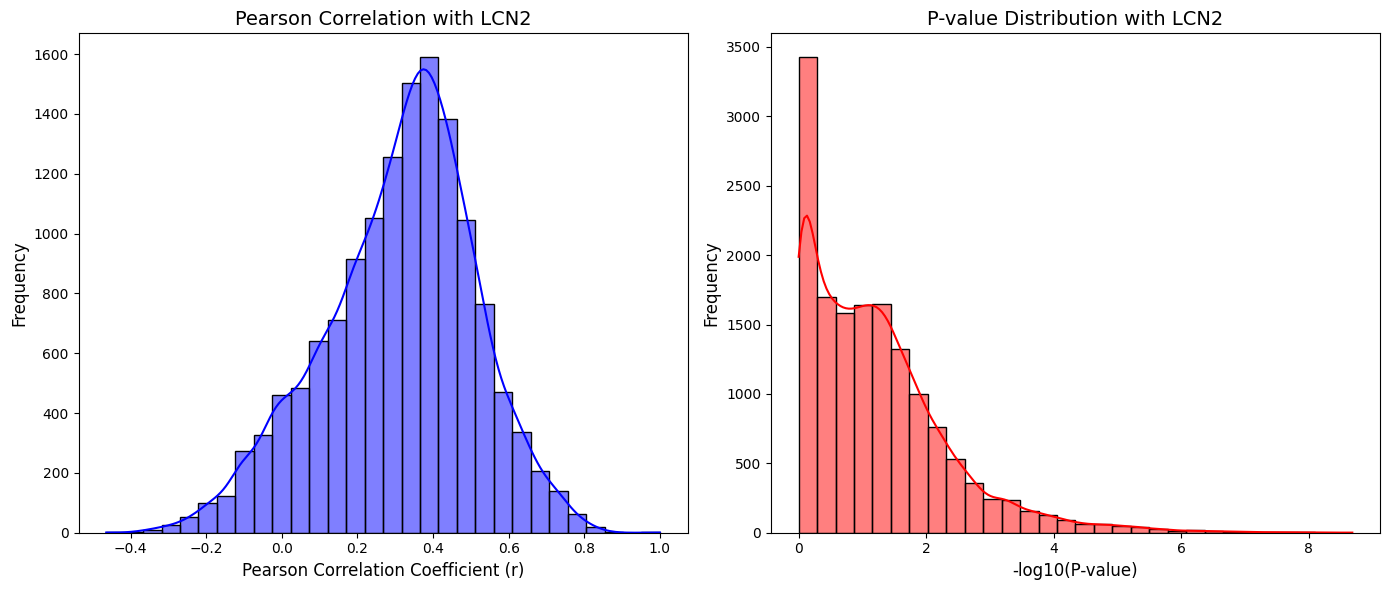

In [705]:
gene_1 = 'LCN2'
# Pearson 상관계수와 P-value를 저장할 리스트 초기화
correlation_list = []
p_value_list = []

# CEBPB 유전자의 인덱스
gene_1_index = np.where(adata.var_names == gene_1)[0][0]

# 고유 좌표 및 각 좌표의 인덱스 가져오기
unique_coords, inverse_indices = np.unique(spatial_bulked, axis=0, return_inverse=True)

# 모든 유전자에 대해 CEBPB와 Pearson 상관계수 계산
for gene_name in adata.var_names:
    gene_2_index = np.where(adata.var_names == gene_name)[0][0]
    
    # 고유 좌표별 발현값 평균 계산
    unique_gene_1_expression = np.array([
        bulkX[inverse_indices == idx, gene_1_index].mean()
        for idx in range(len(unique_coords))
    ])
    unique_gene_2_expression = np.array([
        bulkX[inverse_indices == idx, gene_2_index].mean()
        for idx in range(len(unique_coords))
    ])
    
    # NaN을 0으로 대체
    unique_gene_1_expression = np.nan_to_num(unique_gene_1_expression, nan=0)
    unique_gene_2_expression = np.nan_to_num(unique_gene_2_expression, nan=0)
    
    # Log 전처리
    unique_gene_1_expression = np.log1p(unique_gene_1_expression)
    unique_gene_2_expression = np.log1p(unique_gene_2_expression)
    
    # Pearson 상관계수 및 p-value 계산
    if len(unique_gene_1_expression) > 1 and len(unique_gene_2_expression) > 1:
        correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)
    else:
        correlation, p_value = np.nan, np.nan  # 데이터가 부족한 경우 처리
    
    correlation_list.append(correlation)
    p_value_list.append(p_value)

# 히스토그램 시각화
plt.figure(figsize=(14, 6))

# Pearson 상관계수 히스토그램
plt.subplot(1, 2, 1)
sns.histplot(correlation_list, bins=30, kde=True, color='blue')
plt.title(f"Pearson Correlation with {gene_1}", fontsize=14)
plt.xlabel("Pearson Correlation Coefficient (r)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# P-value 히스토그램 (log 스케일)
plt.subplot(1, 2, 2)
sns.histplot(-np.log10(np.nan_to_num(p_value_list, nan=1.0)), bins=30, kde=True, color='red')
plt.title(f"P-value Distribution with {gene_1}", fontsize=14)
plt.xlabel("-log10(P-value)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1082886/3398070022.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)
/tmp/ipykernel_1082886/3398070022.py:55: RuntimeWarning: divide by zero encountered in log10
  sns.histplot(-np.log10(np.nan_to_num(p_value_list, nan=1.0)), bins=30, kde=True, color='red')


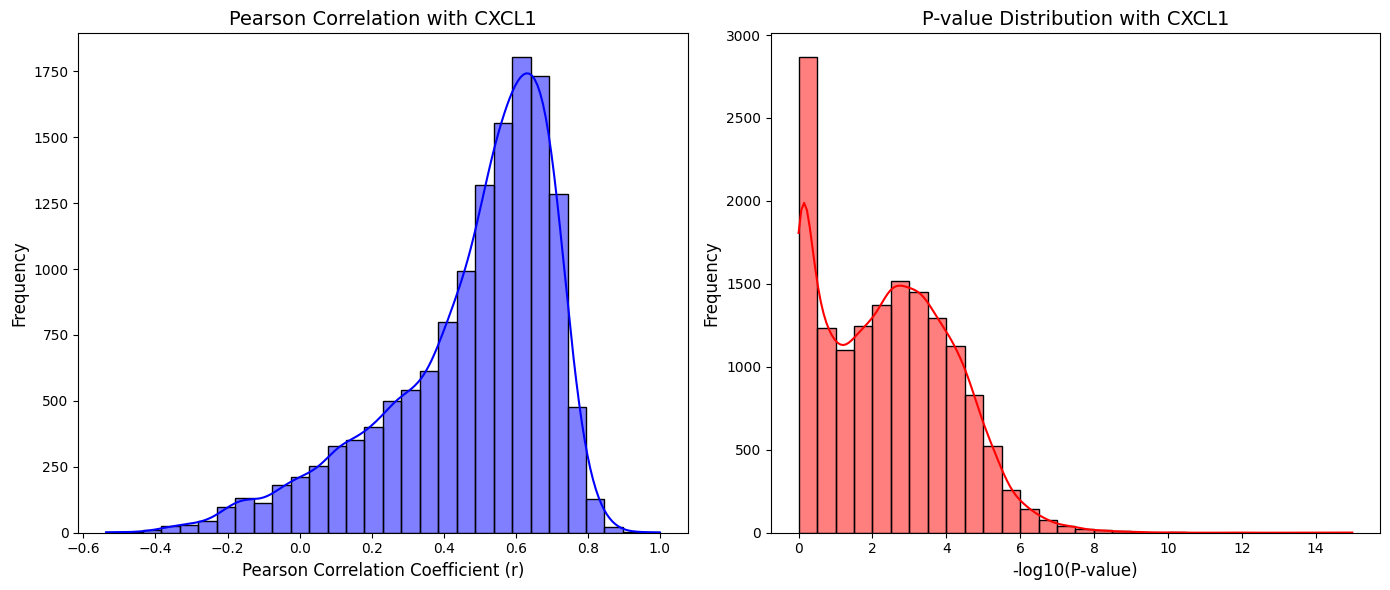

In [708]:
gene_1 = 'CXCL1'
# Pearson 상관계수와 P-value를 저장할 리스트 초기화
correlation_list = []
p_value_list = []

# CEBPB 유전자의 인덱스
gene_1_index = np.where(adata.var_names == gene_1)[0][0]

# 고유 좌표 및 각 좌표의 인덱스 가져오기
unique_coords, inverse_indices = np.unique(spatial_bulked, axis=0, return_inverse=True)

# 모든 유전자에 대해 CEBPB와 Pearson 상관계수 계산
for gene_name in adata.var_names:
    gene_2_index = np.where(adata.var_names == gene_name)[0][0]
    
    # 고유 좌표별 발현값 평균 계산
    unique_gene_1_expression = np.array([
        bulkX[inverse_indices == idx, gene_1_index].mean()
        for idx in range(len(unique_coords))
    ])
    unique_gene_2_expression = np.array([
        bulkX[inverse_indices == idx, gene_2_index].mean()
        for idx in range(len(unique_coords))
    ])
    
    # NaN을 0으로 대체
    unique_gene_1_expression = np.nan_to_num(unique_gene_1_expression, nan=0)
    unique_gene_2_expression = np.nan_to_num(unique_gene_2_expression, nan=0)
    
    # Log 전처리
    unique_gene_1_expression = np.log1p(unique_gene_1_expression)
    unique_gene_2_expression = np.log1p(unique_gene_2_expression)
    
    # Pearson 상관계수 및 p-value 계산
    if len(unique_gene_1_expression) > 1 and len(unique_gene_2_expression) > 1:
        correlation, p_value = pearsonr(unique_gene_1_expression, unique_gene_2_expression)
    else:
        correlation, p_value = np.nan, np.nan  # 데이터가 부족한 경우 처리
    
    correlation_list.append(correlation)
    p_value_list.append(p_value)

# 히스토그램 시각화
plt.figure(figsize=(14, 6))

# Pearson 상관계수 히스토그램
plt.subplot(1, 2, 1)
sns.histplot(correlation_list, bins=30, kde=True, color='blue')
plt.title(f"Pearson Correlation with {gene_1}", fontsize=14)
plt.xlabel("Pearson Correlation Coefficient (r)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# P-value 히스토그램 (log 스케일)
plt.subplot(1, 2, 2)
sns.histplot(-np.log10(np.nan_to_num(p_value_list, nan=1.0)), bins=30, kde=True, color='red')
plt.title(f"P-value Distribution with {gene_1}", fontsize=14)
plt.xlabel("-log10(P-value)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()
